# 05_integrated_eda.ipynb — EDA 통합 노트북

> ⚠️ **새 표본(관찰 종료일 2017-02-28 기준) 재실행 필요.** 이전 출력은 3월 데이터·교집합 표본 결과라 삭제함. 해석 마크다운(🔄 표시)은 재실행 결과를 보고 다시 작성할 것.

팀원 4명의 개별 EDA(members / transactions / user_logs / train)를 하나로 병합.

**변수명 규칙 (충돌 방지용으로 통합 시 이름 변경함):**
- members 섹션: `df` → `df_members`
- transactions 섹션: `transactions` → `df_transactions` (파일 경로도 상대경로로 수정함)
- user_logs 섹션: `user_logs` → `df_logs`
- train 섹션: `df` → `df_train`
- transactions 섹션 내부의 `train` → `df_train_ref` (train_100k.csv를 다시 불러오던 부분)

**data_check.py 의존성 제거**: members 섹션이 쓰던 `from data_check import data_read`를 지웠고, 그 함수(`data_read`, `data_detail`) 코드를 노트북 안에 직접 넣었습니다. 기능은 원본과 완전히 동일하며, 별도 파일을 챙기지 않아도 이 노트북 하나로 실행됩니다.

**경로 수정**: members 섹션의 `data_read("members_100k.csv")`, `data_read("train_100k.csv")`에 경로가 빠져있어 (팀원 PC의 작업 폴더 기준으로는 동작했지만) 다른 위치에서 열면 FileNotFoundError가 났던 부분을 `"../../data/sampled/..."` 상대경로로 수정했습니다.

---
# 1. Members EDA
담당자 노트북: 01_members_eda.ipynb (df → df_members로 변경됨)

# members + train EDA (10만 행 샘플)
순서: 0 준비 → 1 데이터 개요·대표성 → 2 타겟 → 4 변수별 이탈률(3번 분포는 여기에 인원 수로 흡수) → 5 결측·이상값의 의미 → 6 변수 간 관계 → 7 요약

## 0. 준비: 불러오기, 병합, 한글 폰트

In [80]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지: 운영체제별 기본 한글 폰트 지정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 깨지는 것 방지

members = pd.read_csv("../../data/sampled/members_100k.csv")
trains = pd.read_csv("../../data/sampled/train_100k.csv")

# how="left": train(타겟이 있는 쪽)을 기준으로 붙임 → members에 없는 사람도 행이 남음
df_members = trains.merge(members, on="msno", how="left")

# 가입일: 20150312 같은 정수 → 날짜형. format="%Y%m%d"는 '연4자리 월2자리 일2자리'라는 뜻
df_members["registration_init_time"] = pd.to_datetime(df_members["registration_init_time"], format="%Y%m%d")

print("trains:", trains.shape, "/ members:", members.shape, "/ 병합:", df_members.shape)
print("members와 매칭되지 않은 행:", df_members["city"].isna().sum())

trains: (100000, 2) / members: (100000, 6) / 병합: (100000, 7)
members와 매칭되지 않은 행: 0


### 분석용 파생 컬럼
원본 컬럼은 건드리지 않고 분석용 컬럼을 따로 추가합니다.

In [81]:
# 기준 시점: 2017-02-28. 가입 기간(얼마나 오래된 고객인지)을 계산하는 기준점
BASE_DATE = pd.Timestamp("2017-02-28")
print("기준 시점:", BASE_DATE.date())

df_members["reg_year"] = df_members["registration_init_time"].dt.year
df_members["tenure_years"] = (BASE_DATE - df_members["registration_init_time"]).dt.days / 365

# pd.cut: 연속값을 구간으로 나눔
#   bins  = 구간 경계값 목록 (np.inf는 '그 이상 전부')
#   labels= 각 구간의 이름 (경계값 개수 - 1 개)
#   right=False → 왼쪽 경계 포함, 오른쪽 제외. 예) [1, 2) = 1년 이상 2년 미만
df_members["tenure_bin"] = pd.cut(
    df_members["tenure_years"],
    bins=[0, 1, 2, 3, 5, 10, np.inf],
    labels=["1년 미만", "1~2년", "2~3년", "3~5년", "5~10년", "10년 이상"],
    right=False,
)

# 성별: 결측을 '미입력'이라는 하나의 그룹으로 취급
# members에 없는 고객(city 결측)은 "members없음"으로 따로 구분 → 성별 미입력과 섞이지 않게
df_members["has_member"] = df_members["city"].notna().astype(int)
df_members["gender_status"] = np.where(
    df_members["has_member"].eq(0), "members없음", df_members["gender"].fillna("미입력")
)

# 나이 상태: np.select는 조건 목록을 위에서부터 검사해 처음 맞는 값을 넣음, 모두 아니면 default
df_members["bd_status"] = np.select(
    [df_members["bd"].isna(), df_members["bd"] == 0, df_members["bd"].between(10, 80)],   # between(10, 80): 10 이상 80 이하
    ["members없음", "0(미입력)", "정상"],
    default="이상치",
)

# 정상 나이만 연령대로 구간화 (나머지는 NaN)
df_members["age_bin"] = pd.cut(
    df_members["bd"].where(df_members["bd_status"] == "정상"),       # where: 조건이 거짓인 행은 NaN으로
    bins=[10, 20, 30, 40, 50, 60, 81],
    labels=["10대", "20대", "30대", "40대", "50대", "60대 이상"],
    right=False,
)

OVERALL = df_members["is_churn"].mean()   # 전체 평균 이탈률: 모든 그래프의 비교 기준선
print(f"전체 이탈률: {OVERALL:.2%}")

기준 시점: 2017-02-28
전체 이탈률: 6.42%


### 공통 함수
4~6번에서 반복해서 쓰는 '그룹별 이탈률 표 + 그래프' 함수입니다.

In [82]:
def churn_table(data, col, min_count=0):
    """col 그룹별 이탈률 표
    min_count: 인원이 이 값보다 적은 그룹은 제외 (우연히 튀는 이탈률을 거르기 위함)
    lift     : 그룹 이탈률 / 전체 이탈률. 2.0이면 평균의 두 배
    """
    t = (data.groupby(col, dropna=False, observed=True)["is_churn"]
             .agg(churn_rate="mean", count="size"))
    t["lift"] = t["churn_rate"] / OVERALL
    return t[t["count"] >= min_count]


def plot_churn(data, col, title=None, order=None, sort_by_rate=False, figsize=(10, 4)):
    """막대 = 그룹별 이탈률, 빨간 점선 = 전체 평균, 막대 위 숫자 = 그룹 인원 수
    order       : x축 순서를 직접 지정할 때
    sort_by_rate: True면 이탈률 높은 순으로 정렬
    """
    t = churn_table(data, col)
    t.index = [str(i) for i in t.index]    # NaN 그룹도 'nan'으로 표시되게 문자열화
    if order is not None:
        t = t.loc[[str(o) for o in order if str(o) in t.index]]
    elif sort_by_rate:
        t = t.sort_values("churn_rate", ascending=False)

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(t.index, t["churn_rate"], color="steelblue")
    ax.axhline(OVERALL, color="red", linestyle="--", label=f"전체 평균 {OVERALL:.1%}")
    for bar, n in zip(bars, t["count"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"n={n:,}", ha="center", va="bottom", fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_xlabel(col)
    ax.set_ylabel("이탈률")
    ax.set_title(title or f"{col}별 이탈률")
    ax.legend()
    plt.xticks(rotation=45 if len(t) > 8 else 0)
    plt.tight_layout()
    plt.show()
    return t

## 1. 데이터 개요와 샘플 대표성

In [83]:
overview = pd.DataFrame({
    "dtype": df_members.dtypes.astype(str),
    "결측 수": df_members.isna().sum(),
    "결측 비율": (df_members.isna().mean() * 100).round(2),
    "고유값 수": df_members.nunique(),
})
print("완전 중복 행:", df_members.duplicated().sum(), "/ msno 중복:", df_members["msno"].duplicated().sum())
overview

완전 중복 행: 0 / msno 중복: 0


,dtype,결측 수,결측 비율,고유값 수
msno,object,0,0.00,100000
is_churn,int64,0,0.00,2
city,int64,0,0.00,21
bd,int64,0,0.00,117
gender,object,52791,52.79,2
registered_via,int64,0,0.00,5
registration_init_time,datetime64[ns],0,0.00,4667
reg_year,int32,0,0.00,14
tenure_years,float64,0,0.00,4667
tenure_bin,category,118,0.12,6


In [84]:
# bd 이상값 현황: 0, 음수, 80 초과가 각각 얼마나 되는지
print(df_members["bd"].describe())
df_members["bd_status"].value_counts()

count    100000.000000
mean         14.142400
std          25.140077
min       -3152.000000
25%           0.000000
50%           0.000000
75%          28.000000
max        2016.000000
Name: bd, dtype: float64


bd_status
0(미입력)    52978
정상        46922
이상치         100
Name: count, dtype: int64

In [85]:
display(churn_table(df_members, "has_member"))

,churn_rate,count,lift
has_member,,,
1,0.06422,100000,1.0


## 2. 타겟 분포

,count,ratio
is_churn,,
0,93578,0.9358
1,6422,0.0642


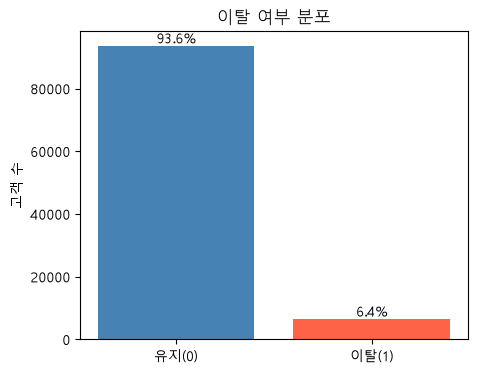

In [86]:
target = df_members["is_churn"].value_counts().sort_index()
ratio = df_members["is_churn"].value_counts(normalize=True).sort_index()   # normalize=True → 개수 대신 비율
display(pd.DataFrame({"count": target, "ratio": ratio.round(4)}))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["유지(0)", "이탈(1)"], target.values, color=["steelblue", "tomato"])
for bar, r in zip(bars, ratio.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{r:.1%}", ha="center", va="bottom")
ax.set_title("이탈 여부 분포")
ax.set_ylabel("고객 수")
plt.show()
# 결론 메모: 클래스 불균형 → 정확도(accuracy)만으로 모델을 평가하면 안 됨

## 4. 변수별 이탈률 비교
막대 위 n은 그룹 인원 수입니다. 인원이 적은 그룹의 이탈률은 해석에 주의하세요.

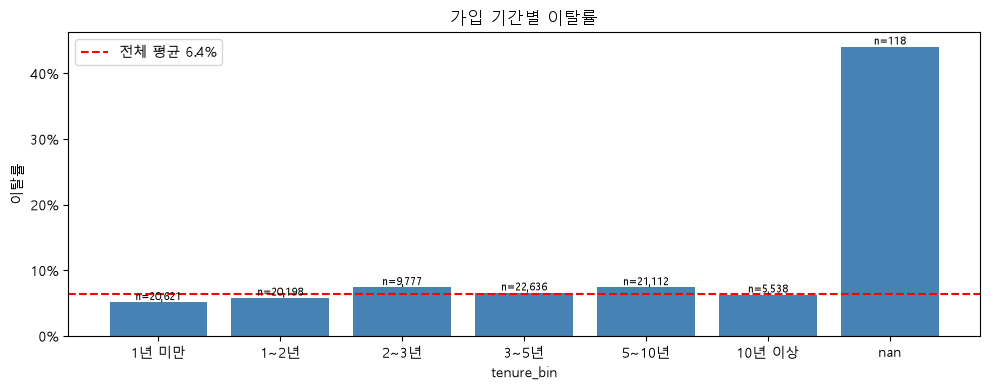

,churn_rate,count,lift
1년 미만,0.051404,20621,0.800435
1~2년,0.058224,20198,0.906627
2~3년,0.074256,9777,1.156274
3~5년,0.066045,22636,1.028422
5~10년,0.074128,21112,1.154289
10년 이상,0.062839,5538,0.978489
nan,0.440678,118,6.862005


In [87]:
# 4-1. 가입 기간: 오래된 고객일수록 덜 떠나는가
plot_churn(df_members, "tenure_bin", title="가입 기간별 이탈률")

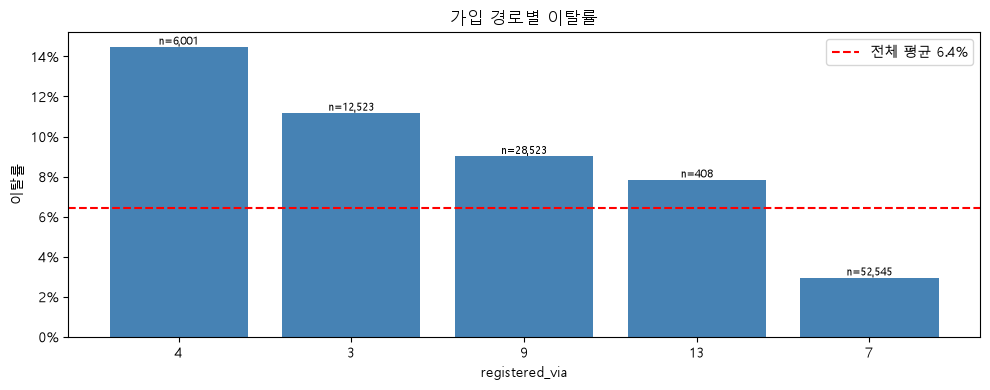

,churn_rate,count,lift
4,0.144809,6001,2.254893
3,0.111794,12523,1.740802
9,0.090173,28523,1.404124
13,0.078431,408,1.221292
7,0.029479,52545,0.459039


In [88]:
# 4-2. 가입 경로
plot_churn(df_members, "registered_via", title="가입 경로별 이탈률", sort_by_rate=True)

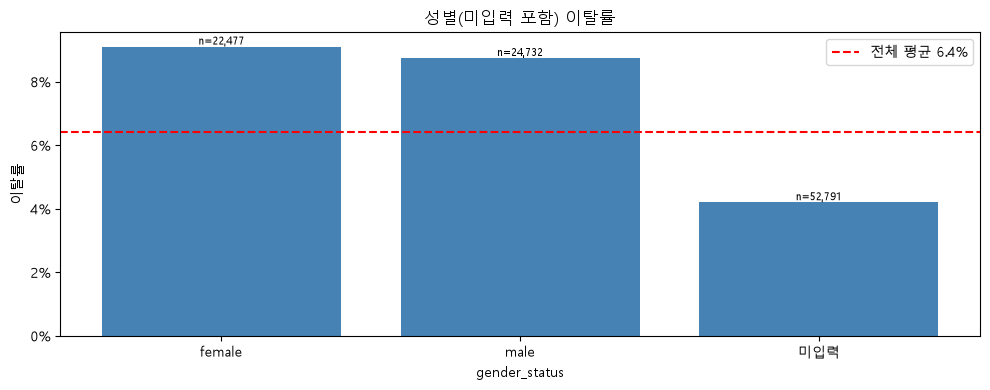

,churn_rate,count,lift
female,0.090982,22477,1.416722
male,0.087377,24732,1.360584
미입력,0.041977,52791,0.653641


In [89]:
# 4-3. 성별 (미입력 포함)
plot_churn(df_members, "gender_status", title="성별(미입력 포함) 이탈률")

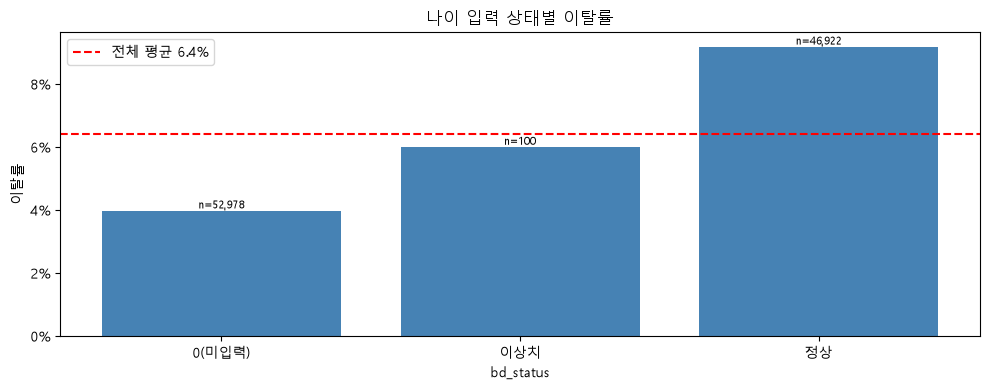

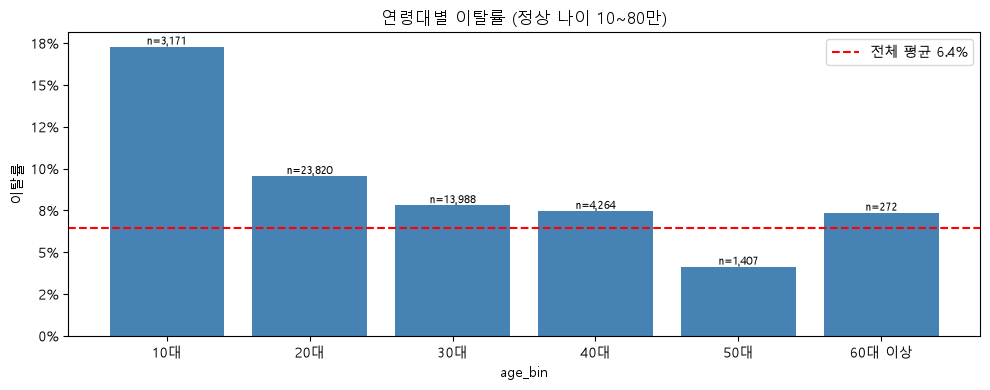

,churn_rate,count,lift
10대,0.172816,3171,2.691002
20대,0.095424,23820,1.485892
30대,0.077995,13988,1.214504
40대,0.074578,4264,1.161287
50대,0.041222,1407,0.641894
60대 이상,0.073529,272,1.144961


In [90]:
# 4-4. 나이: 먼저 상태별(0/정상/이상치), 그다음 정상 나이만 연령대별
plot_churn(df_members, "bd_status", title="나이 입력 상태별 이탈률")
plot_churn(df_members.dropna(subset=["age_bin"]), "age_bin", title="연령대별 이탈률 (정상 나이 10~80만)")  # dropna(subset=...): 해당 컬럼이 빈 행만 제외

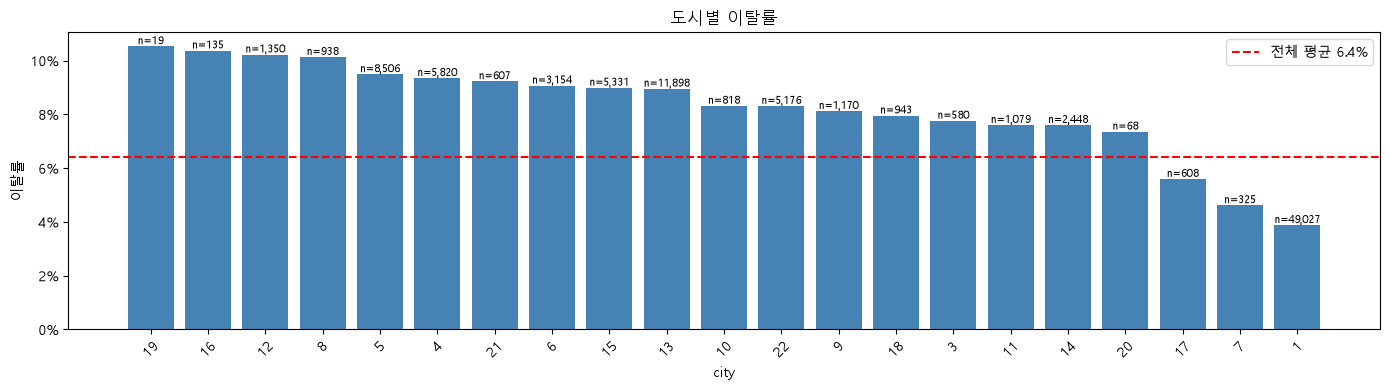

,churn_rate,count,lift
19,0.105263,19,1.639102
16,0.103704,135,1.614819
12,0.102222,1350,1.591751
8,0.101279,938,1.577068
5,0.094874,8506,1.477331
4,0.093471,5820,1.455478
21,0.092257,607,1.436577
6,0.090679,3154,1.411998
15,0.089852,5331,1.399125
13,0.089511,11898,1.393816


In [91]:
# 4-5. 도시: 그룹이 많으므로 이탈률 순 정렬
plot_churn(df_members, "city", title="도시별 이탈률", sort_by_rate=True, figsize=(14, 4))

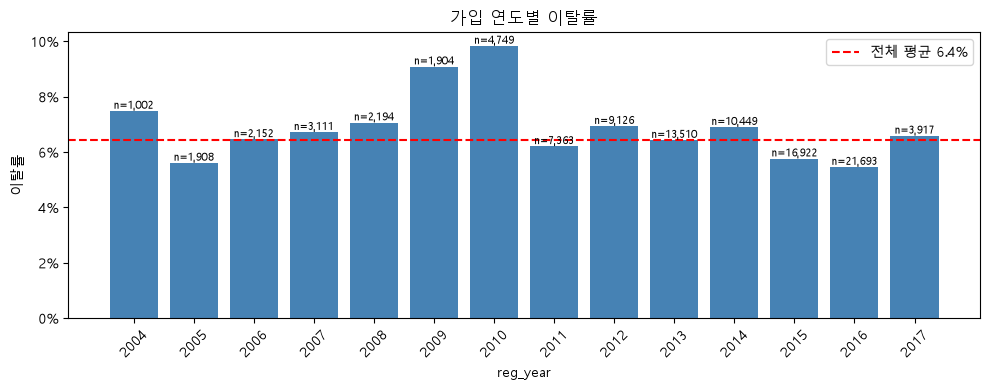

,churn_rate,count,lift
2004,0.074850,1002,1.165529
2005,0.056080,1908,0.873243
2006,0.064591,2152,1.005778
2007,0.067181,3111,1.046107
2008,0.070647,2194,1.100081
2009,0.090861,1904,1.414845
2010,0.098336,4749,1.531244
2011,0.062067,7363,0.966476
2012,0.069362,9126,1.080073
2013,0.064323,13510,1.001600


In [92]:
# 4-6. 가입 연도 (가입 기간과 같은 정보를 연 단위로 본 것 — 둘 중 발표용으로 하나 선택)
plot_churn(df_members, "reg_year", title="가입 연도별 이탈률")

## 5. 결측·이상값 자체의 의미
'비어 있다'는 사실이 이탈과 관련 있는지 봅니다.

In [93]:
# 각 항목을 0/1 플래그로. city==1은 결측은 아니지만, 미입력 시 기본값일 가능성을 가설로 두고 포함
# members에 없는 고객은 NaN으로 둔다 (프로필을 '안 채운' 것이 아니라 '정보가 없는' 고객)
has_m = df_members["has_member"].eq(1)
df_members["flag_gender_missing"] = df_members["gender"].isna().astype(int).where(has_m)
df_members["flag_bd_zero"] = (df_members["bd"] == 0).astype(int).where(has_m)
df_members["flag_city_1"] = (df_members["city"] == 1).astype(int).where(has_m)

# 세 플래그가 서로 얼마나 겹치는지: 많이 겹치면 '프로필을 안 채운 사람'이라는 한 집단일 가능성
flags = ["flag_gender_missing", "flag_bd_zero", "flag_city_1"]
display(df_members[flags].corr().round(2))

# crosstab: 두 변수의 조합별 인원 수 표
display(pd.crosstab(df_members["flag_gender_missing"], df_members["flag_bd_zero"], margins=True))  # margins=True → 합계 행·열 추가

,flag_gender_missing,flag_bd_zero,flag_city_1
flag_gender_missing,1.00,0.95,0.86
flag_bd_zero,0.95,1.00,0.87
flag_city_1,0.86,0.87,1.00


flag_bd_zero,0,1,All
flag_gender_missing,,,
0,45802,1407,47209
1,1220,51571,52791
All,47022,52978,100000


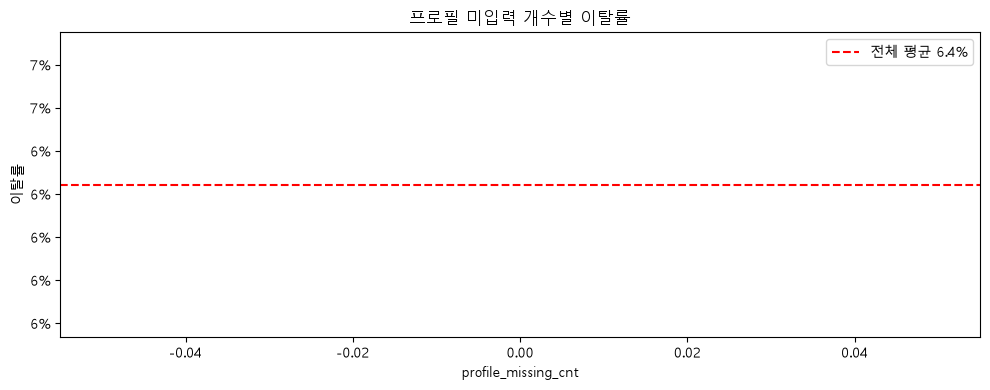

,churn_rate,count,lift


In [94]:
# 프로필 미입력 개수 0~3: 3이면 성별·나이·도시 모두 기본값/빈칸
df_members["profile_missing_cnt"] = df_members[flags].sum(axis=1, min_count=1)   # axis=1 → 행 방향 합 / min_count=1 → members없음은 NaN 유지
plot_churn(df_members, "profile_missing_cnt", title="프로필 미입력 개수별 이탈률", order=[0.0, 1.0, 2.0, 3.0, "nan"])   # 합계가 실수형(0.0~3.0)이라 실수로 지정 / nan = members없음

In [95]:
# 플래그 하나씩 따로 보기: 어느 항목이 이탈률 차이를 가장 크게 만드는지
pd.concat({f: churn_table(df_members, f) for f in flags})

churn_rate  count      lift
                    flag_gender_missing                             
flag_gender_missing 0                      0.089093  47209  1.387312
                    1                      0.041977  52791  0.653641
flag_bd_zero        0                      0.091744  47022  1.428594
                    1                      0.039790  52978  0.619590
flag_city_1         0                      0.088694  50973  1.381096
                    1                      0.038775  49027  0.603777

## 6. 변수 간 관계
4번에서 본 가입 경로의 차이가 '경로 자체' 때문인지, '가입 시기' 때문인지 구분합니다.

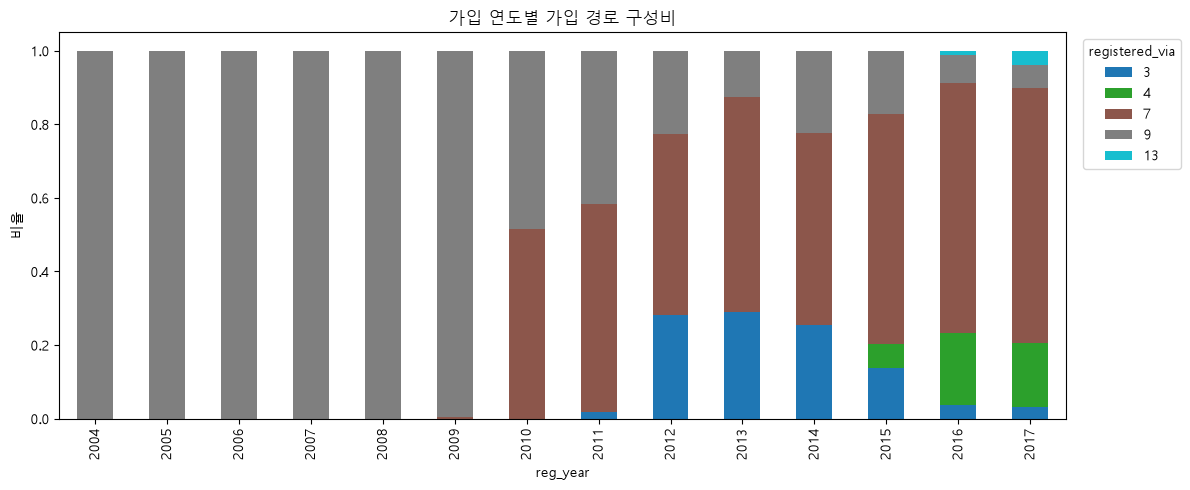

In [96]:
# 6-1. 가입 연도별로 어떤 경로가 많았는지
# normalize="index" → 각 행(연도)의 합이 1이 되도록 비율로 변환
via_by_year = pd.crosstab(df_members["reg_year"], df_members["registered_via"], normalize="index")
via_by_year.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab10")
plt.title("가입 연도별 가입 경로 구성비")
plt.ylabel("비율")
plt.legend(title="registered_via", bbox_to_anchor=(1.01, 1))   # bbox_to_anchor: 범례를 그래프 밖 오른쪽에
plt.tight_layout()
plt.show()

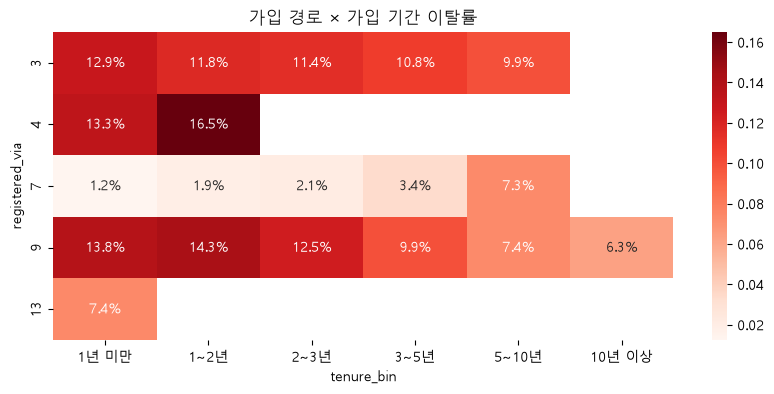

tenure_bin,1년 미만,1~2년,2~3년,3~5년,5~10년,10년 이상
registered_via,,,,,,
3,783.0,1985.0,2659.0,6658.0,434.0,NaN
4,4101.0,1885.0,NaN,NaN,NaN,NaN
7,13795.0,13743.0,4509.0,12274.0,8172.0,NaN
9,1538.0,2585.0,2609.0,3704.0,12506.0,5538.0
13,404.0,NaN,NaN,NaN,NaN,NaN


In [97]:
# 6-2. 같은 가입 기간 안에서도 경로별 이탈률 차이가 유지되는가
# pivot_table: index=행, columns=열, values=계산할 값, aggfunc=계산 방식
pivot_rate = df_members.pivot_table(index="registered_via", columns="tenure_bin",
                            values="is_churn", aggfunc="mean", observed=True)
pivot_cnt = df_members.pivot_table(index="registered_via", columns="tenure_bin",
                           values="is_churn", aggfunc="size", observed=True)

plt.figure(figsize=(10, 4))
# annot=True: 칸마다 값 표시 / fmt=".1%": 퍼센트 소수 1자리 / cmap: 색상표(진할수록 이탈률 높음)
sns.heatmap(pivot_rate, annot=True, fmt=".1%", cmap="Reds")
plt.title("가입 경로 × 가입 기간 이탈률")
plt.show()
pivot_cnt   # 칸별 인원 수: 인원이 적은 칸은 해석 주의
# 읽는 법: 같은 열(같은 가입 기간) 안에서도 경로별 색 차이가 크면 → 경로 자체의 영향

In [98]:
# 6-3. 가입 경로 × 프로필 미입력 개수: 특정 경로가 프로필을 안 채우는 경로인지
pd.crosstab(df_members["registered_via"], df_members["profile_missing_cnt"], normalize="index").round(3)

profile_missing_cnt,0,1,2,3
registered_via,,,,
3,0.769,0.070,0.096,0.065
4,0.447,0.093,0.127,0.332
7,0.160,0.016,0.018,0.806
9,0.836,0.033,0.070,0.061
13,0.108,0.010,0.007,0.875


## 7. 요약: 이탈 위험이 높은 고객 집단 Top N
관리자 서비스의 '이탈 원인 제시' 기능으로 이어지는 결론 부분입니다.

In [99]:
SEGMENT_COLS = ["registered_via", "tenure_bin", "gender_status"]   # 조합할 기준 컬럼
MIN_COUNT = 300   # 이 인원 미만인 조합은 제외: 너무 작은 집단의 우연한 고이탈률을 거르는 기준
TOP_N = 10

seg = churn_table(df_members, SEGMENT_COLS, min_count=MIN_COUNT)
top = seg.sort_values("churn_rate", ascending=False).head(TOP_N)
top["churn_rate"] = (top["churn_rate"] * 100).round(1).astype(str) + "%"
top["lift"] = top["lift"].round(2)
top

churn_rate  count  lift
registered_via tenure_bin gender_status                        
4              1~2년       male               17.6%    567  2.75
                          female             16.8%    517  2.62
9              1~2년       male               16.4%    641  2.55
                          female             16.4%    599  2.55
4              1~2년       미입력                15.5%    801  2.41
9              1년 미만      female             14.8%    364  2.31
                          male               14.5%    387  2.25
               2~3년       male               13.9%    771  2.16
4              1년 미만      male               13.8%   1120  2.14
                          미입력                13.7%   2051  2.14

---
# 2. Transactions EDA
담당자 노트북: 02_transactions_eda.ipynb (transactions → df_transactions, 경로 상대경로로 수정됨)

# Load Data

In [100]:
df_transactions = pd.read_csv(r'../../data/sampled/transactions_100k.csv')

In [101]:
df_transactions['transaction_date'] = pd.to_datetime(
    df_transactions['transaction_date'].astype(int).astype(str),
    format = "%Y%m%d"
)

df_transactions['membership_expire_date'] = pd.to_datetime(
    df_transactions['membership_expire_date'].astype(int).astype(str),
    format = "%Y%m%d"
)

In [102]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122479 entries, 0 to 122478
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   msno                    122479 non-null  object        
 1   payment_method_id       122479 non-null  int64         
 2   payment_plan_days       122479 non-null  int64         
 3   plan_list_price         122479 non-null  int64         
 4   actual_amount_paid      122479 non-null  int64         
 5   is_auto_renew           122479 non-null  int64         
 6   transaction_date        122479 non-null  datetime64[ns]
 7   membership_expire_date  122479 non-null  datetime64[ns]
 8   is_cancel               122479 non-null  int64         
dtypes: datetime64[ns](2), int64(6), object(1)
memory usage: 8.4+ MB


In [103]:
df_transactions.groupby('payment_plan_days')['actual_amount_paid'].value_counts()

payment_plan_days  actual_amount_paid
0                  149                   156
                   119                    39
                   129                     7
                   100                     4
1                  0                      19
                                        ... 
400                1599                   21
410                1788                  647
                   0                       2
415                1599                    3
450                1788                   13
Name: count, Length: 61, dtype: int64

# User Behavior df 만들기

In [104]:
trans = df_transactions.copy()

In [105]:
transaction_cnt = trans.groupby('msno').size().reset_index(name='transaction_cnt')
transaction_cnt.head()

,msno,transaction_cnt
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,1
1,++/ZHqwUNa7U21Qz+zqteiXlZapxey86l6eEorrak/g=,2
2,++A8p4GrsTnMjI6hAZEtlRsaz6s6O9ddUoH0fmS4s7s=,1
3,++BW1PJYU5OZi3n3+IDLiU+d1IL1VE/GLx6p64TDs6U=,1
4,++L+G2jsvbkHMHlwvb2KQiRLAvB4VyEfjVJTUrs5auE=,1


In [106]:
transaction_cnt["transaction_cnt"].value_counts().sort_index()

transaction_cnt
1     86021
2     11940
3      1122
4       201
5       201
6        81
7        54
8        47
9        22
10       28
11       37
12       23
13       24
14       18
15       14
16        7
17       12
18        5
19       12
20        8
21       28
22       12
23       10
24        6
25        6
26        8
27        4
28        7
29        3
30        5
31        1
33        4
34        4
35        6
36        4
37        2
38        2
39        3
40        1
45        2
48        3
54        1
61        1
Name: count, dtype: int64

In [107]:
#거래 횟수가 1인 사람들의 비율 86%로 매우 높음 -> 거래 행동 변화 파악하기는 힘듦
(transaction_cnt['transaction_cnt'] == 1).mean()

np.float64(0.86021)

In [108]:
transaction_cnt['multiple_transaction'] = (transaction_cnt['transaction_cnt'] > 1).astype(int)
transaction_cnt.head()

,msno,transaction_cnt,multiple_transaction
0,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,1,0
1,++/ZHqwUNa7U21Qz+zqteiXlZapxey86l6eEorrak/g=,2,1
2,++A8p4GrsTnMjI6hAZEtlRsaz6s6O9ddUoH0fmS4s7s=,1,0
3,++BW1PJYU5OZi3n3+IDLiU+d1IL1VE/GLx6p64TDs6U=,1,0
4,++L+G2jsvbkHMHlwvb2KQiRLAvB4VyEfjVJTUrs5auE=,1,0


### last transaction만 뽑아보기

In [109]:
trans = trans.sort_values(
    ["msno", "transaction_date", "membership_expire_date"],
    kind="mergesort"
)

last_trans = (
    trans.groupby("msno")
    .tail(1)
    .copy()
)

last_trans.head()

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
100658,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,41,30,149,149,1,2017-03-26,2017-04-26,0
10378,++/ZHqwUNa7U21Qz+zqteiXlZapxey86l6eEorrak/g=,14,30,149,149,1,2017-03-31,2017-05-04,0
12249,++A8p4GrsTnMjI6hAZEtlRsaz6s6O9ddUoH0fmS4s7s=,30,30,149,149,1,2017-03-26,2017-04-26,0
121247,++BW1PJYU5OZi3n3+IDLiU+d1IL1VE/GLx6p64TDs6U=,34,30,149,149,1,2017-03-31,2017-04-30,0
36834,++L+G2jsvbkHMHlwvb2KQiRLAvB4VyEfjVJTUrs5auE=,38,30,149,149,0,2017-03-19,2017-04-18,0


In [110]:
last_trans = last_trans.rename(
    columns={
        'payment_method_id': 'last_payment_method_id',
        'payment_plan_days': 'last_payment_plan_days',
        'plan_list_price': 'last_plan_list_price',
        'actual_amount_paid': 'last_actual_amount_paid',
        'is_auto_renew': 'last_is_auto_renew',
        'transaction_date': 'last_transaction_date',
        'membership_expire_date': 'last_membership_expire_date',
        'is_cancel': 'last_is_cancel'
    }
)

In [111]:
last_trans = last_trans[
    [
        'msno',
        'last_payment_plan_days',
        'last_plan_list_price',
        'last_actual_amount_paid',
        'last_is_auto_renew',
        'last_is_cancel'
    ]
]

In [112]:
last_trans['last_discount_amount'] = (
    last_trans['last_plan_list_price']
    - last_trans['last_actual_amount_paid']
)

In [113]:
last_trans['last_is_discount'] = (
    last_trans['last_actual_amount_paid']
    < last_trans['last_plan_list_price']
).astype(int)

In [114]:
last_trans.columns

Index(['msno', 'last_payment_plan_days', 'last_plan_list_price',
       'last_actual_amount_paid', 'last_is_auto_renew', 'last_is_cancel',
       'last_discount_amount', 'last_is_discount'],
      dtype='object')

In [115]:
user_behavior = last_trans.merge(
    transaction_cnt,
    on='msno',
    how='left'
)

In [116]:
user_behavior['last_is_auto_renew'].value_counts()

last_is_auto_renew
1    88675
0    11325
Name: count, dtype: int64

## is_churn과 결합

In [117]:
df_train_ref = pd.read_csv(r'../../data/sampled/train_100k.csv')

In [118]:
eda_df = df_train_ref[
    ['msno', 'is_churn']
].merge(
    user_behavior,
    on='msno',
    how='left'
)
# 2/28 이전 거래가 없는 고객은 NaN → 표에서 빠지지 않도록 플래그로 구분
eda_df['has_tx'] = eda_df['transaction_cnt'].notna().astype(int)

In [119]:
eda_df.isnull().sum()

msno                       0
is_churn                   0
last_payment_plan_days     0
last_plan_list_price       0
last_actual_amount_paid    0
last_is_auto_renew         0
last_is_cancel             0
last_discount_amount       0
last_is_discount           0
transaction_cnt            0
multiple_transaction       0
has_tx                     0
dtype: int64

In [120]:
# 거래 기록 유무별 이탈률 (거래 없는 고객이 groupby에서 조용히 빠지지 않도록 별도 확인)
eda_df.groupby('has_tx')['is_churn'].agg(['count', 'mean'])

,count,mean
has_tx,,
1,100000,0.06422


In [121]:
eda_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   msno                     100000 non-null  object
 1   is_churn                 100000 non-null  int64 
 2   last_payment_plan_days   100000 non-null  int64 
 3   last_plan_list_price     100000 non-null  int64 
 4   last_actual_amount_paid  100000 non-null  int64 
 5   last_is_auto_renew       100000 non-null  int64 
 6   last_is_cancel           100000 non-null  int64 
 7   last_discount_amount     100000 non-null  int64 
 8   last_is_discount         100000 non-null  int64 
 9   transaction_cnt          100000 non-null  int64 
 10  multiple_transaction     100000 non-null  int64 
 11  has_tx                   100000 non-null  int64 
dtypes: int64(11), object(1)
memory usage: 9.2+ MB


In [122]:
eda_df['is_churn'].mean()

np.float64(0.06422)

<Axes: xlabel='transaction_cnt', ylabel='Count'>

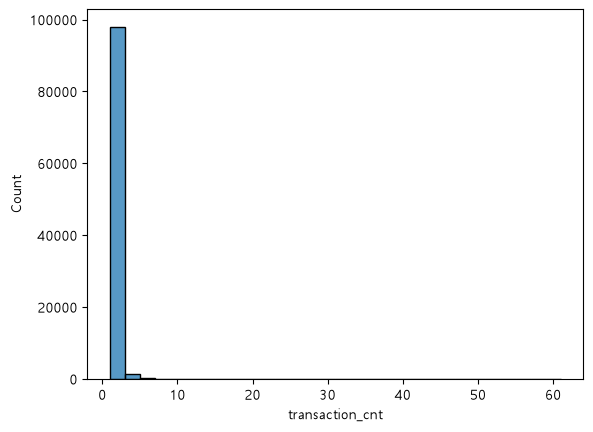

In [123]:
sns.histplot(data=eda_df, x='transaction_cnt', bins = 30)

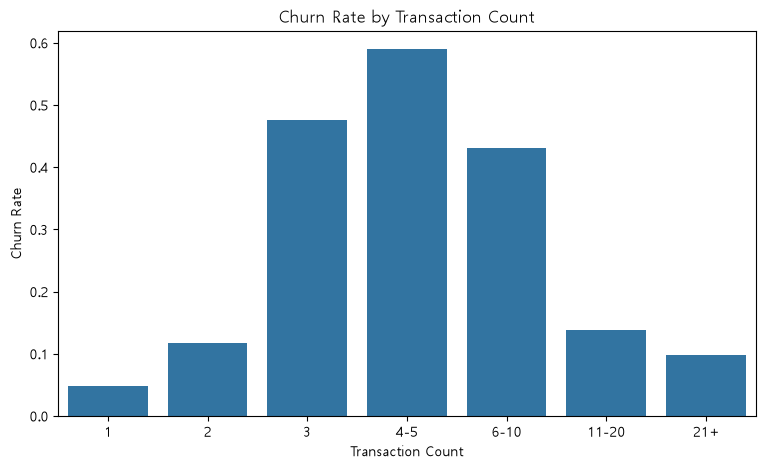

In [124]:
bins = [0, 1, 2, 3, 5, 10, 20, float('inf')]
labels = ['1', '2', '3', '4-5', '6-10', '11-20', '21+']

eda_df['transaction_cnt_group'] = pd.cut(
    eda_df['transaction_cnt'],
    bins=bins,
    labels=labels
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=eda_df,
    x='transaction_cnt_group',
    y='is_churn',
    errorbar=None
)

plt.xlabel('Transaction Count')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Transaction Count')

plt.show()

In [125]:
#multiple_transaction
eda_df.groupby('multiple_transaction', dropna=False)['is_churn'].agg(['mean', 'count'])

,mean,count
multiple_transaction,,
0,0.047826,86021
1,0.165105,13979


🔄 **재실행 후 다시 작성**

> 복수의 transaction 기록을 가진 고객군에서 이탈률이 상대적으로 높게 관찰되었다.

In [126]:
eda_df.groupby('is_churn')[
    ['last_plan_list_price', 'last_actual_amount_paid']
].agg(
    ['mean', 'median', 'std']
)

last_plan_list_price                    last_actual_amount_paid  \
                         mean median         std                    mean   
is_churn                                                                   
0                  133.489549  149.0   30.442316              133.399581   
1                  454.032700  150.0  530.843343              452.260199   

                             
         median         std  
is_churn                     
0         149.0   30.542652  
1         150.0  532.098428

🔄 **재실행 후 다시 작성**

> 표준 편차 커서 무의미할 수 있음

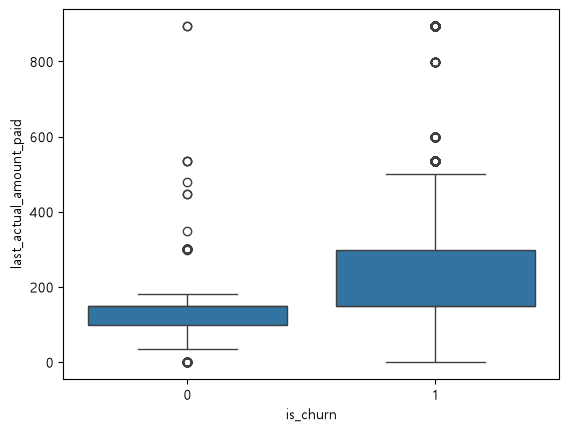

In [127]:
upper = eda_df['last_actual_amount_paid'].quantile(0.99)

sns.boxplot(
    data=eda_df[
        eda_df['last_actual_amount_paid'] <= upper
    ],
    x='is_churn',
    y='last_actual_amount_paid'
)

plt.show()

In [128]:
plan_summary = (
    eda_df.groupby('last_payment_plan_days', dropna=False)['is_churn']
    .agg(['count', 'mean'])
    .rename(columns={'mean': 'churn_rate'})
    .sort_values('count', ascending=False)
)

plan_summary.head(20)

,count,churn_rate
last_payment_plan_days,,
30,97491,0.040845
410,618,0.995146
90,483,0.946170
195,442,0.995475
180,415,0.992771
360,166,1.000000
100,113,0.991150
7,57,0.894737
60,45,0.533333


In [129]:
eda_df.groupby('transaction_cnt', dropna=False)['is_churn'].agg(
    ['count', 'mean']
).head(10)

,count,mean
transaction_cnt,,
1,86021,0.047826
2,11940,0.117588
3,1122,0.475045
4,201,0.572139
5,201,0.606965
6,81,0.358025
7,54,0.481481
8,47,0.468085
9,22,0.500000


In [130]:
eda_df.groupby('last_is_auto_renew', dropna=False)['is_churn'].agg(
    ['count', 'mean']
)

,count,mean
last_is_auto_renew,,
0,11325,0.304901
1,88675,0.033482


In [131]:
eda_df.groupby('last_is_discount', dropna=False)['is_churn'].agg(
    ['count', 'mean']
)

,count,mean
last_is_discount,,
0,99803,0.063565
1,197,0.395939


🔄 **재실행 후 다시 작성**

> 최근 정가보다 낮은 금액을 결제한 고객의 이탈률은 약 41.0%로, 정상가 이상을 결제한 고객의 약 6.1%보다 크게 높게 나타났다. 다만 할인 거래 고객의 표본이 전체 고객 중 매우 적으므로, 할인 자체의 영향으로 해석하기보다는 해당 집단의 플랜·결제 방식·자동갱신 및 취소 특성을 추가로 확인할 필요가 있다.

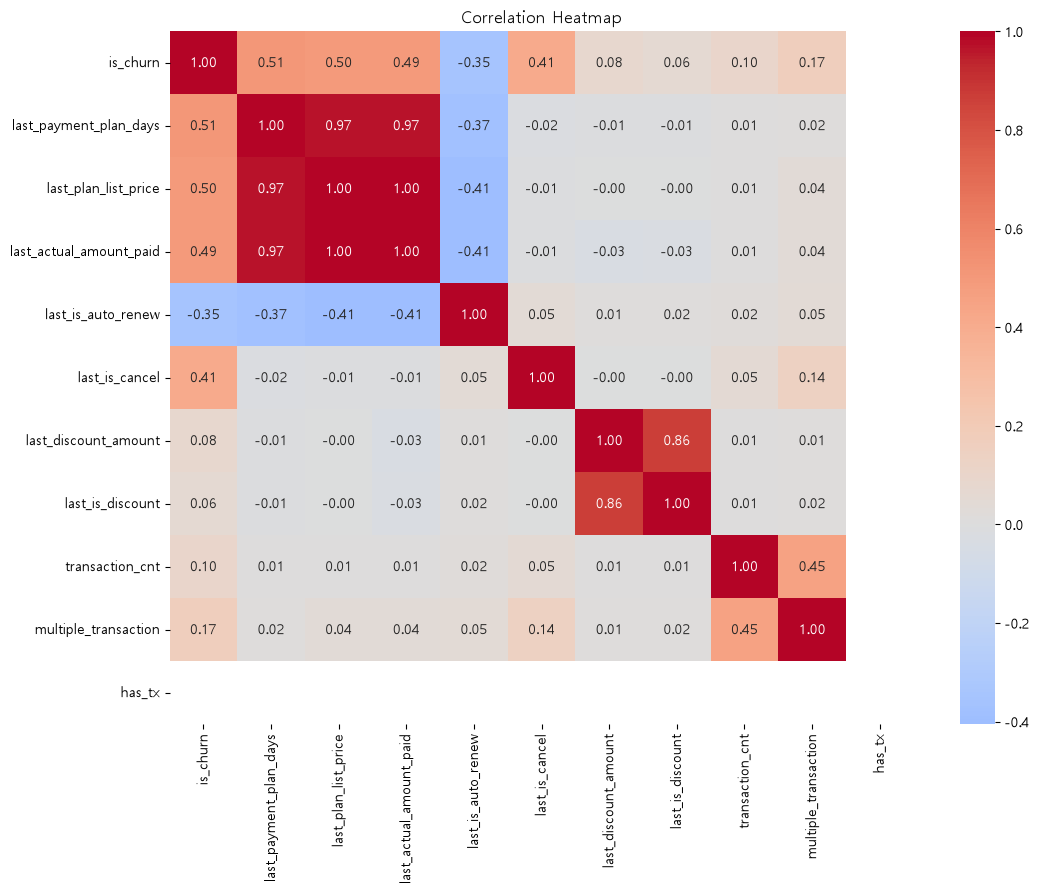

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# msno 제거
corr_df = eda_df.drop(columns='msno')

# 숫자형 컬럼만 선택
corr = corr_df.select_dtypes(include='number').corr()

# heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,       # 상관계수 숫자 표시
    fmt='.2f',        # 소수점 둘째 자리
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

---
# 3. User Logs EDA
담당자 노트북: 03_user_logs_eda.ipynb (user_logs → df_logs로 변경됨)

# User Logs EDA

## 1. 샘플 데이터 불러오기

In [133]:
# 한글 폰트는 노트북 첫 셀에서 운영체제별로 설정됨

# 샘플링된 df_logs 불러오기
df_logs = pd.read_csv("../../data/sampled/user_logs_100k.csv")

df_logs.head()

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,6eT/NGMljpNgEeqTYIdhkc/dvUik+b+41sBNrXJ0cBQ=,20170324,78,5,3,2,8,85,3490.020
1,Q6XdUeVvsXNF/7o0IjPbcSg6dCsFlsRsdGLuiT5UIiI=,20170318,1,1,1,0,136,123,37989.716
2,xZmokPACIvbzXoCrwp+nxnB3SLiLLT+QnFy6ZOYofLE=,20170318,0,1,0,0,22,3,4194.039
3,Dde9YoZqShj9wZAgEm0mc+V995QOExh+1WRlL9oMQJg=,20170318,34,13,7,6,83,74,24825.041
4,J0BhO71yiNuIbyK+QkzR2Ih1PXarheWYO3EcZIQk5NQ=,20170316,0,0,0,0,3,3,697.004


## 1. 데이터 구조 및 품질 확인

In [134]:
print("데이터 크기:", df_logs.shape)
print("고객 수:", df_logs["msno"].nunique())
print("중복 행:", df_logs.duplicated().sum())

df_logs.info()
display(df_logs.isnull().sum())

데이터 크기: (1815285, 9)
고객 수: 100000
중복 행: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1815285 entries, 0 to 1815284
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   msno        object 
 1   date        int64  
 2   num_25      int64  
 3   num_50      int64  
 4   num_75      int64  
 5   num_985     int64  
 6   num_100     int64  
 7   num_unq     int64  
 8   total_secs  float64
dtypes: float64(1), int64(7), object(1)
memory usage: 124.6+ MB


msno          0
date          0
num_25        0
num_50        0
num_75        0
num_985       0
num_100       0
num_unq       0
total_secs    0
dtype: int64

## 2. 수집 기간 확인

In [135]:
df_logs["date"] = pd.to_datetime(
    df_logs["date"].astype(str),
    format="%Y%m%d"
)

df_logs["date"].agg(["min", "max"])

min   2017-03-01
max   2017-03-31
Name: date, dtype: datetime64[ns]

## 3. 고객별 로그 수 분포

In [136]:
# 고객 ID별 그룹 생성
logs_per_user = df_logs.groupby("msno").size()

logs_per_user.describe()

count    100000.000000
mean         18.152850
std           9.628569
min           1.000000
25%          10.000000
50%          19.000000
75%          27.000000
max          31.000000
dtype: float64

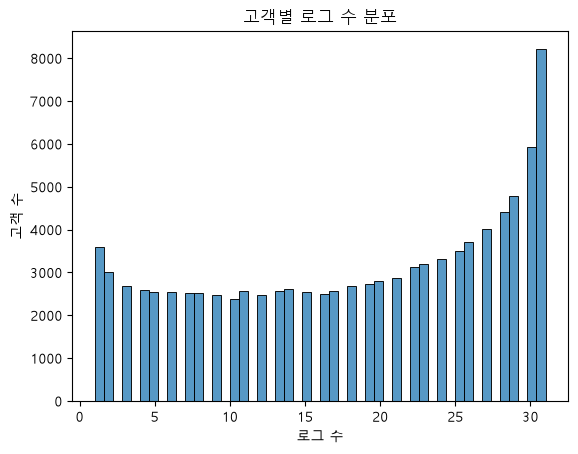

In [137]:
sns.histplot(logs_per_user, bins=50)
plt.title("고객별 로그 수 분포")
plt.xlabel("로그 수")
plt.ylabel("고객 수")
plt.show()

## 4. 날짜별 이용 고객 수

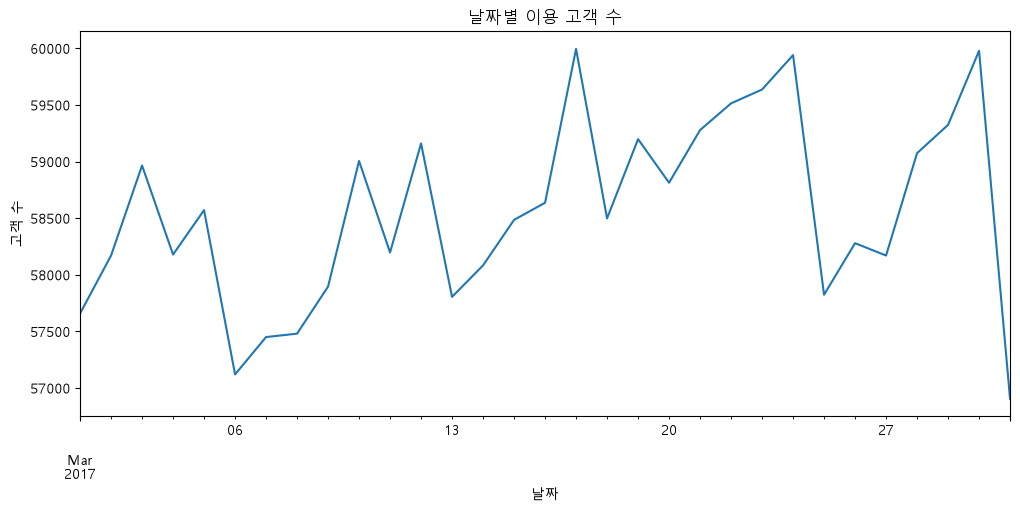

In [138]:
# 날짜별 고객 ID별 그룹 생성
daily_users = df_logs.groupby("date")["msno"].nunique()

daily_users.plot(figsize=(12, 5))
plt.title("날짜별 이용 고객 수")
plt.xlabel("날짜")
plt.ylabel("고객 수")
plt.show()

## 5. 재생 행동 통계

In [139]:
# 재생 길이별 통계
play_cols = [
    "num_25", "num_50", "num_75",
    "num_985", "num_100",
    "num_unq", "total_secs"
]

df_logs[play_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_25,1815285.0,5.993656,12.317383,0.000,0.000,2.000,7.000,978.000
num_50,1815285.0,1.451126,3.681234,0.000,0.000,0.000,2.000,831.000
num_75,1815285.0,0.918479,1.812747,0.000,0.000,0.000,1.000,246.000
num_985,1815285.0,1.048354,3.647019,0.000,0.000,0.000,1.000,957.000
num_100,1815285.0,29.979885,40.063497,0.000,7.000,16.000,37.000,7779.000
num_unq,1815285.0,28.581022,31.723928,1.000,8.000,18.000,37.000,1410.000
total_secs,1815285.0,7820.166348,9690.287722,0.011,1944.133,4522.426,9716.387,1588632.203


## 6. 완곡 재생 비중 확인

In [140]:
# 
df_logs["total_play_count"] = (
    df_logs["num_25"]
    + df_logs["num_50"]
    + df_logs["num_75"]
    + df_logs["num_985"]
    + df_logs["num_100"]
)

df_logs["completion_rate"] = (
    df_logs["num_100"]
    / df_logs["total_play_count"].replace(0, np.nan)
)

df_logs["completion_rate"].describe()

count    1.815285e+06
mean     7.246693e-01
std      2.598606e-01
min      0.000000e+00
25%      5.714286e-01
50%      8.000000e-01
75%      9.396552e-01
max      1.000000e+00
Name: completion_rate, dtype: float64

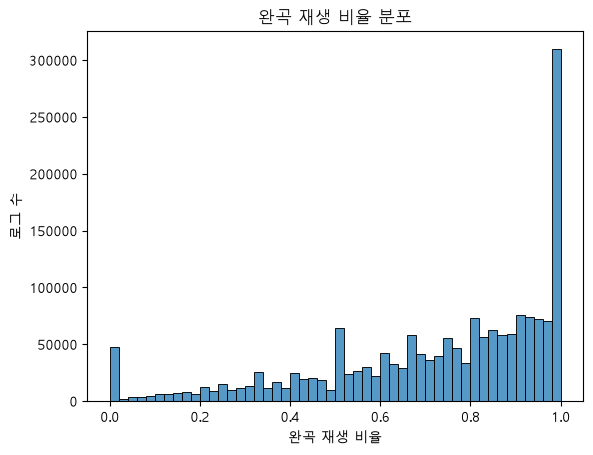

In [141]:
sns.histplot(df_logs["completion_rate"].dropna(), bins=50)
plt.title("완곡 재생 비율 분포")
plt.xlabel("완곡 재생 비율")
plt.ylabel("로그 수")
plt.show()

## 7. 재생 지표 상관관계

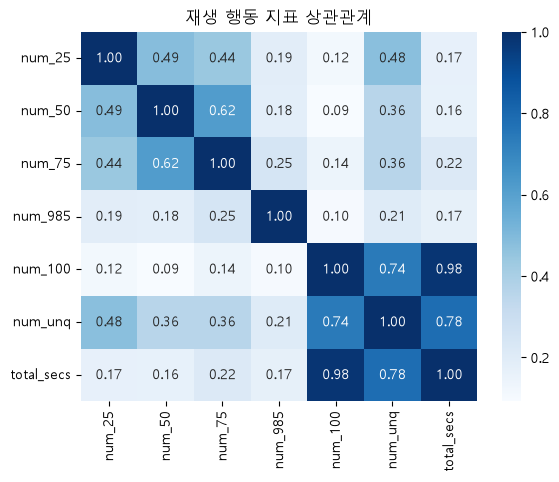

In [142]:
sns.heatmap(
    df_logs[play_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title("재생 행동 지표 상관관계")
plt.show()

## 통합용 고객별 집계 데이터 생성

In [143]:
logs_agg = (
    df_logs
    .groupby("msno")
    .agg(
        activity_days=("date", "nunique"),
        total_num_100=("num_100", "sum"),
        total_num_unq=("num_unq", "sum"),
        total_secs=("total_secs", "sum"),
        last_log_date=("date", "max"),
    )
    .reset_index()
)
logs_agg["days_since_last_log"] = (pd.Timestamp("2017-02-28") - logs_agg.pop("last_log_date")).dt.days

## 8. 청취 행동과 이탈의 관계
로그가 없는 고객도 포함하기 위해 `train_100k` 기준으로 병합합니다.

In [144]:
log_eda = (
    trains[["msno", "is_churn"]]
    .merge(logs_agg, on="msno", how="left", validate="one_to_one")
    .merge(last_trans[["msno", "last_is_auto_renew"]], on="msno", how="left", validate="one_to_one")
)
log_eda["has_log"] = log_eda["activity_days"].notna().astype(int)

# 로그 유무별 이탈률
display(churn_table(log_eda, "has_log"))

,churn_rate,count,lift
has_log,,,
1,0.06422,100000,1.0


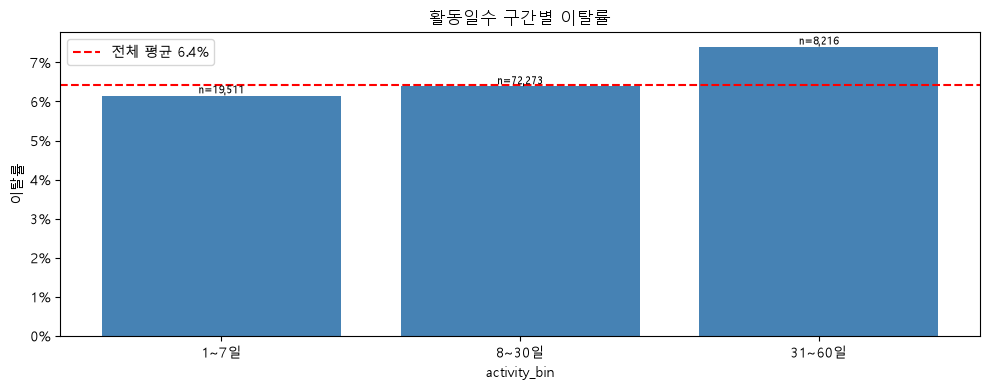

,churn_rate,count,lift
1~7일,0.061504,19511,0.957704
8~30일,0.063841,72273,0.994103
31~60일,0.074002,8216,1.152319


In [145]:
# 활동일수 구간별 이탈률 (로그 없음 = 0일 그룹으로 포함)
log_eda["activity_bin"] = pd.cut(
    log_eda["activity_days"].fillna(0),
    bins=[-1, 0, 7, 30, 60, np.inf],
    labels=["0일(로그 없음)", "1~7일", "8~30일", "31~60일", "61일 이상"],
)
plot_churn(log_eda, "activity_bin", title="활동일수 구간별 이탈률")

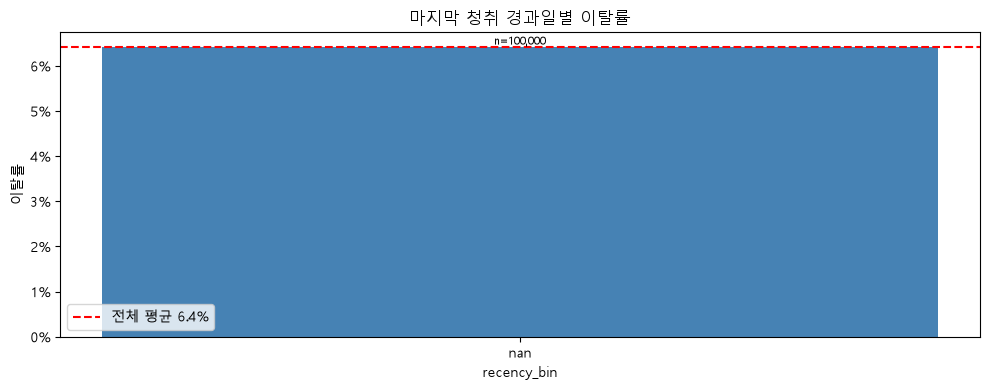

,churn_rate,count,lift
nan,0.06422,100000,1.0


In [146]:
# 마지막 청취일부터 2/28까지 경과일 구간별 이탈률 (로그 없는 고객은 NaN 그룹)
log_eda["recency_bin"] = pd.cut(
    log_eda["days_since_last_log"],
    bins=[-1, 0, 7, 30, 60, np.inf],
    labels=["당일", "1~7일", "8~30일", "31~60일", "61일 이상"],
)
plot_churn(log_eda, "recency_bin", title="마지막 청취 경과일별 이탈률",
           order=["당일", "1~7일", "8~30일", "31~60일", "61일 이상", "nan"])

In [147]:
# 로그 유무 × 자동결제: '로그 없는 고객의 이탈률이 더 낮은' 현상이 자동결제로 설명되는지 확인
display(log_eda.groupby(["has_log", "last_is_auto_renew"], dropna=False)["is_churn"]
        .agg(count="size", churn_rate="mean"))

count  churn_rate
has_log last_is_auto_renew                   
1       0                   11325    0.304901
        1                   88675    0.033482

---
# 4. Train EDA
담당자 노트북: 04_train_eda.ipynb (df → df_train으로 변경됨)

## 📊 train_v2.csv 컬럼 설명

| 컬럼명        | 의미                     |
| ---------- | ---------------------- |
| `msno`     | 고객 고유 식별자(익명화된 고객 ID)  |
| `is_churn` | 고객 이탈 여부(0: 유지, 1: 이탈) |

**참고 사항**

* `msno`는 다른 데이터셋과 고객 정보를 연결할 때 사용하는 기준 컬럼이다.
* `is_churn`은 모델이 예측해야 하는 타겟(정답) 컬럼이다.
* KKBOX 대회에서 이탈은 구독 만료 후 30일 이내에 새로운 유효 구독을 시작하지 않은 경우를 의미한다.
* 본 노트북은 팀에서 추출한 10만 명 표본(`train_100k.csv`) 기준으로 작성됨.

**출처:** Kaggle KKBOX Churn Prediction Challenge — 데이터 설명

https://www.kaggle.com/competitions/kkbox-churn-prediction-challenge/data

In [148]:
import pandas as pd

# csv 불러오기 & 미리보기
df_train = pd.read_csv("../../data/sampled/train_100k.csv")
df_train.head() # 고객 식별자(msno)와 이탈여부(is_churn)을 포함

,msno,is_churn
0,9BEEEzxPms9jHREEUNVVw98vqYcjJinOJcL/WeHlb4M=,0
1,nuKiQ/vJS3Olc78nMfSbSHOQEdpCyRcFvTWUkjO66kE=,0
2,kMohbZUdmPB/5M0Vh9sWNYIsIDmbAysozML3gDSIvLQ=,0
3,w5xouqYrDegrRJGTA5+51m5/BqyhQekAW9w1sII1Glg=,0
4,N4eHhn1HQZy8V6CIQcKNAxMoC6QYdT7cwz5yNPnsLm0=,0


In [149]:
# 데이터 크기 확인
df_train.shape # train_100k.csv는 100,000행, 2개의 컬럼으로 구성

(100000, 2)

In [150]:
# 컬럼, 자료형 확인
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   msno      100000 non-null  object
 1   is_churn  100000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.5+ MB


In [151]:
# 결측치 확인
df_train.isnull().sum()

msno        0
is_churn    0
dtype: int64

In [152]:
# 고객 ID(msno) 중복 및 고유 고객 수 확인
# 100,000으로 고객 ID가 한 명당 한 행으로 이루어진 걸 확인
print("중복 고객 ID:", df_train['msno'].duplicated().sum())
print("고유 고객 수:", df_train['msno'].nunique())

중복 고객 ID: 0
고유 고객 수: 100000


In [153]:
# 타겟 값 확인 -> 이진분류 타겟
df_train['is_churn'].unique()

array([0, 1])

In [154]:
# 이탈 고객(is_churn) 수, 비율 확인 
# => 불균형 상태 > 모델평가에서 정확도만 보면 안된다!
display(df_train['is_churn'].value_counts())
display(df_train['is_churn'].value_counts(normalize=True) * 100)  # 비율로 보기

is_churn
0    93578
1     6422
Name: count, dtype: int64

is_churn
0    93.578
1     6.422
Name: proportion, dtype: float64

<Axes: xlabel='is_churn', ylabel='count'>

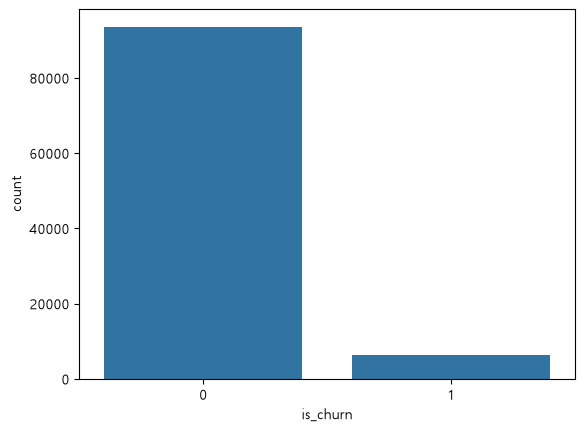

In [155]:
# 이탈 분포 시각화
import seaborn as sns
sns.countplot(x='is_churn', data=df_train)

🔄 **재실행 후 다시 작성** — ⚠️ 아래 수치(이탈 6.4%, 불균형 심화 등)는 **옛 표본 기준**이므로 사용 금지

## 📊 EDA 결과 해석 — train_100k.csv (10만 명 표본)

### 1. 데이터 구조

* 전체 데이터: **100,000행 × 2컬럼** (`msno`, `is_churn`)
* `msno`: 고객 고유 식별자
* `is_churn`: 이탈 여부 (0: 유지, 1: 이탈)

### 2. 데이터 품질

* 두 컬럼 모두 결측치 0개
* 고객 ID 중복 0개, 고유 고객 수 100,000명
* 고객 1명당 1행으로 구성
* 타겟 값은 0과 1만 존재

### 3. 클래스 불균형 확인

| 구분    | 비율      |
| ----- | ------- |
| 유지(0) | 약 93.6% |
| 이탈(1) | 약 6.4%  |

* 원본(`train_v2.csv`, 유지 91.0% : 이탈 9.0%)과 비교했을 때, 10만 명 표본에서는 **불균형이 오히려 더 심해짐** (이탈 비율 9.0% → 6.4%)
* 모든 고객을 유지로 예측해도 정확도가 약 93.6%이므로 Accuracy 단독 평가는 부적절함 (원본보다 더 강하게 해당)
* 모델링 단계에서 PR-AUC, ROC-AUC, Recall, Precision, F1-score 등을 검토하고 프로젝트 목적에 맞는 평가 지표를 선정해야 함.
* 이탈 비율이 더 낮아진 만큼, 클래스 가중치 조정 및 오버/언더샘플링 기법의 필요성이 원본보다 커짐.

### 4. 다음 단계에 주는 시사점

* `train_100k`는 고객 ID(`msno`)와 이탈 정답(`is_churn`)을 제공하는 기준 테이블.
* `members_100k`, `transactions_100k`, `user_logs_100k`와 고객 ID를 기준으로 결합해야 함.
* 결제·청취 데이터는 고객당 여러 행이 존재할 수 있으므로 고객별 집계 후 결합 필요.
* 이 파일에서는 결측치와 고객 ID 중복 문제가 확인되지 않았으며, 이탈 원인 분석에는 추가 데이터가 필요함.

### 결론

`train_100k.csv`는 고객별 이탈 정답을 제공하는 10만 명 표본 데이터로, 결측치와 고객 ID 중복은 없음. 다만 원본 대비 클래스 불균형이 더 심화되어(이탈 6.4%), 모델 학습·평가 시 이를 반드시 고려해야 하며 표본 추출 방식에 대한 팀 확인이 필요함.

# 통합 학습용 데이터 생성

In [158]:
from pathlib import Path
import pandas as pd

S = Path("../../data/sampled")
OUT = Path("../../data/processed")
OUT.mkdir(parents=True, exist_ok=True)
TODAY = pd.Timestamp("2017-02-28")
SEC_PER_DAY = 86_400

# 이전 결과는 _prev로 백업 → 중간에 멈추면 integrated_data.csv는 아예 없음
# old = OUT / "integrated_data.csv"
# if old.exists():
#     old.replace(OUT / "integrated_data_prev.csv")

train = pd.read_csv(S / "train_100k.csv")
members = pd.read_csv(S / "members_100k.csv")
tx = pd.read_csv(S / "transactions_100k.csv")
logs = pd.read_csv(S / "user_logs_100k.csv")

assert tx["transaction_date"].max() <= 20170228
assert logs["date"].max() <= 20170228

# ───────────────── 1. 거래 → 고객당 1행 ─────────────────
tx_agg = tx.groupby("msno").agg(
    transaction_count=("msno", "size"),
    cancel_count=("is_cancel", "sum"),
).reset_index()

# 해지하지 않은 거래의 결제액만 합산
paid = (
    tx[tx["is_cancel"].eq(0)]
    .groupby("msno")["actual_amount_paid"].sum()
    .rename("total_payment").reset_index()
)
tx_agg = tx_agg.merge(paid, on="msno", how="left", validate="one_to_one")

# 마지막 거래: 거래일 → 만료일 순으로 정렬
tx = tx.sort_values(["msno", "transaction_date", "membership_expire_date"], kind="mergesort")
last = tx.drop_duplicates("msno", keep="last")

ties = (
    tx.merge(last[["msno", "transaction_date", "membership_expire_date"]],
             on=["msno", "transaction_date", "membership_expire_date"])
    .groupby("msno").size()
)
print(f"마지막 거래 후보가 여러 건인 고객: {(ties > 1).sum():,}명")

last_tx = last[["msno", "is_auto_renew", "is_cancel", "payment_plan_days", "membership_expire_date"]].rename(
    columns={"is_auto_renew": "last_auto_renew",
             "is_cancel": "last_is_cancel",
             "payment_plan_days": "last_plan_days"}
)
expire = pd.to_datetime(last_tx.pop("membership_expire_date").astype(str), format="%Y%m%d")
last_tx["days_to_expire"] = (expire - TODAY).dt.days
tx_agg = tx_agg.merge(last_tx, on="msno", how="left", validate="one_to_one")

# 마지막 거래일에 해지 기록이 하나라도 있었는지 ('현재 해지 상태'를 뜻하지는 않음)
last_day = tx.groupby("msno")["transaction_date"].transform("max")
cancel_last_day = (
    tx[tx["transaction_date"].eq(last_day)]
    .groupby("msno")["is_cancel"].max()
    .rename("cancel_on_last_date").reset_index()
)
tx_agg = tx_agg.merge(cancel_last_day, on="msno", how="left", validate="one_to_one")

print("days_to_expire 최솟값:", tx_agg["days_to_expire"].min(),
      "/ 최댓값:", tx_agg["days_to_expire"].max(),
      "/ -365일 미만:", (tx_agg["days_to_expire"] < -365).sum(),
      "/ 730일 초과:", (tx_agg["days_to_expire"] > 730).sum())

# ───────────────── 2. 로그 → 고객당 1행 ─────────────────
# 고객·날짜별로 먼저 합친 뒤 하루 최대 86,400초로 제한
assert logs["total_secs"].ge(0).all(), "음수 total_secs가 있음 → 처리 기준 따로 정해야 함"

daily = logs.groupby(["msno", "date"], as_index=False)[["total_secs", "num_100", "num_unq"]].sum()
n_over = daily["total_secs"].gt(SEC_PER_DAY).sum()
print(f"하루 {SEC_PER_DAY:,}초 초과: {n_over:,}건 → {SEC_PER_DAY:,}초로 제한 "
      f"(제한 전 최대 {daily['total_secs'].max():,.0f}초)")
daily["total_secs"] = daily["total_secs"].clip(upper=SEC_PER_DAY)

log_agg = daily.groupby("msno").agg(
    activity_days=("date", "nunique"),
    total_secs=("total_secs", "sum"),
    total_num_100=("num_100", "sum"),
    total_num_unq=("num_unq", "sum"),
    last_log_date=("date", "max"),
).reset_index()

last_log = pd.to_datetime(log_agg.pop("last_log_date").astype(str), format="%Y%m%d")
log_agg["days_since_last_log"] = (TODAY - last_log).dt.days

# ───────────────── 3. train 10만 명 기준 병합 ─────────────────
integrated = (
    train
    .merge(members, on="msno", how="left", validate="one_to_one")
    .merge(tx_agg, on="msno", how="left", validate="one_to_one")
    .merge(log_agg, on="msno", how="left", validate="one_to_one")
)

integrated["has_transaction"] = integrated["transaction_count"].notna().astype(int)
integrated["has_log"] = integrated["activity_days"].notna().astype(int)

# 횟수·합계 피처만 0으로 채움 (last_*, days_* 는 '기록 없음'이라 NaN 유지)
count_cols = [
    "transaction_count", "cancel_count", "total_payment",
    "activity_days", "total_secs", "total_num_100", "total_num_unq",
]
integrated[count_cols] = integrated[count_cols].fillna(0)

# ───────────────── 4. 검증 ─────────────────
assert len(integrated) == len(train) == 100_000
assert integrated["msno"].is_unique
assert integrated["is_churn"].notna().all()
assert (integrated["total_secs"] <= integrated["activity_days"] * SEC_PER_DAY + 1e-6).all(), "하루 제한 미적용"
assert ((integrated["has_log"] == 0) == integrated["days_since_last_log"].isna()).all()
assert ((integrated["has_transaction"] == 0) == integrated["last_auto_renew"].isna()).all()

# integrated.to_csv(OUT / "integrated_data.csv", index=False)

# # 저장된 파일을 다시 읽어서 확인
# chk = pd.read_csv(OUT / "integrated_data.csv")
# over = chk["total_secs"] > chk["activity_days"] * SEC_PER_DAY + 1e-6
# print(f"통합 결과: {chk.shape} / 이탈률: {chk['is_churn'].mean():.4f} / "
#       f"하루 제한 초과 고객: {over.sum()} / total_secs 최댓값: {chk['total_secs'].max():,.0f}")

AssertionError: 

In [ ]:
integrated.info()

NameError: name 'integrated' is not defined